# ALL-IDB1 Paper ResNet18 + Orthogonal Softmax

Literal implementation of the paper's published architecture: ResNet18 feature extraction,
average pooling, FC, Dropout, ReLU, Dropout, ReLU, and a fixed diagonal OSL classifier.
The paper uses transfer learning; this notebook deliberately uses random initialization only,
as requested, so its measured scores are not claimed to reproduce the paper's reported scores.

## Objective and success criteria

- Validate the complete 59 healthy / 49 leukemia ALL-IDB1 dataset.
- Match the paper diagram and OSL equation layer by layer.
- Keep the literal fixed diagonal OSL mask during training and testing.
- Prohibit all pretrained weights and record the initialization source.
- Use duplicate-aware stratified 10-fold out-of-fold evaluation.
- Save measured metrics, curves, predictions, embeddings, and checkpoints.

## 1. Reproducible setup

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
import random
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image as PILImage
from IPython.display import Image, display
import torch
import torch.nn as nn
import torch.optim as optim

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT))

import importlib
import leukemia_osl.data as data_module
import leukemia_osl.model as model_module
import leukemia_osl.preprocess as preprocess_module
import leukemia_osl.results as results_module
import train as train_module

for module in (model_module, preprocess_module, data_module, results_module, train_module):
    importlib.reload(module)

from leukemia_osl.model import create_model
from leukemia_osl.preprocess import (
    build_manifest,
    content_group_ids,
    find_duplicate_content,
    summarize_records,
    validate_prepared_all_idb1,
)
from leukemia_osl.results import compute_result_metrics, save_result_bundle
from train import evaluate, set_seed, train_one_epoch

SEED = 42
set_seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Project:", PROJECT_ROOT)
print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

Matplotlib is building the font cache; this may take a moment.


Project: /Users/panshulaj/Documents/AIML proj
Python: /Users/panshulaj/Documents/AIML proj/.venv/bin/python
PyTorch: 2.13.0
Device: mps


## 2. Prepare and validate real ALL-IDB1

This notebook uses the extracted dataset folder supplied for this project: `/Users/panshulaj/Downloads/ALL_IDB1`. The cell below rebuilds the processed ImageFolder split from that folder and stops if the real 108-image dataset is unavailable.

In [2]:
SOURCE_DIR = Path("/Users/panshulaj/Downloads/ALL_IDB1")
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "all_idb1"

if not SOURCE_DIR.is_dir():
    raise FileNotFoundError(f"Expected extracted ALL-IDB1 dataset folder: {SOURCE_DIR}")

subprocess.run(
    [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "prepare_all_idb1.py"),
        "--source",
        str(SOURCE_DIR),
        "--processed-output",
        str(DATA_DIR),
        "--overwrite",
    ],
    cwd=PROJECT_ROOT,
    check=True,
)

split_counts = validate_prepared_all_idb1(DATA_DIR)
records = build_manifest(DATA_DIR)
duplicate_groups = find_duplicate_content(records)
duplicate_files = [[path.name for path in group] for group in duplicate_groups]
assert len(records) == 108
assert summarize_records(records) == {"healthy": 59, "leukemia": 49}

dataset_rows = []
for split_name, counts in split_counts.items():
    for class_name, count in counts.items():
        dataset_rows.append({"split": split_name, "class": class_name, "images": count})
dataset_summary = pd.DataFrame(dataset_rows)
display(dataset_summary)
print(f"Prepared and validated real ALL-IDB1 from {SOURCE_DIR}: 108 files, correct labels, no split leakage.")
if duplicate_files:
    print("Exact duplicate content in prepared data (kept within one split):", duplicate_files)


Detected 108 labeled images under /Users/panshulaj/Downloads/ALL_IDB1.
Class counts: {'healthy': 59, 'leukemia': 49}
train: 75 images {'healthy': 41, 'leukemia': 34}
val: 15 images {'healthy': 8, 'leukemia': 7}
test: 18 images {'healthy': 10, 'leukemia': 8}
Prepared dataset written to /Users/panshulaj/Documents/AIML proj/data/processed/all_idb1


,split,class,images
0,train,healthy,41
1,train,leukemia,34
2,val,healthy,8
3,val,leukemia,7
4,test,healthy,10
5,test,leukemia,8


Prepared and validated real ALL-IDB1 from /Users/panshulaj/Downloads/ALL_IDB1: 108 files, correct labels, no split leakage.
Exact duplicate content in prepared data (kept within one split): [['Im093_0.jpg', 'Im108_0.jpg']]


## 3. Inspect representative source images

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, class_name in zip(axes, ("healthy", "leukemia"), strict=True):
    record = next(record for record in records if record.label == class_name)
    axis.imshow(PILImage.open(record.path).convert("RGB"))
    axis.set_title(f"{class_name}: {record.path.name}")
    axis.axis("off")
plt.tight_layout()
plt.show()

/var/folders/fn/y2r7tz8s7m988x6s6msf6ndr0000gn/T/ipykernel_92935/3308835195.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 4. Literal paper architecture with no pretrained weights

The paper specifies `ResNet18 -> AvgPool -> FC -> Dropout -> ReLU -> Dropout -> ReLU -> OSL`. Its OSL equation uses a fixed diagonal mask, so the preceding FC emits one feature per class. This project keeps `weights=None`, uses validation-loss checkpoint selection, and adds explicit regularization to reduce overfitting on the tiny ALL-IDB1 split.

In [4]:
MODEL_CONFIG = {
    "name": "resnet18_osl",
    "pretrained_backbone": False,
    "freeze_backbone": False,
    "hidden_dim": 2,
    "dropout": 0.6,
    "mask_mode": "diagonal",
}
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 160
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-4
LABEL_SMOOTHING = 0.05
MAX_GRAD_NORM = 1.0
LR_REDUCE_PATIENCE = 6
PATIENCE = 25
MIN_DELTA = 1e-4
N_SPLITS = 10

paper_model = create_model(num_classes=2, **MODEL_CONFIG)
masked_weight = paper_model.osl.weight * paper_model.osl.mask
gram = masked_weight @ masked_weight.T
off_diagonal = gram - torch.diag(torch.diag(gram))

assert MODEL_CONFIG["pretrained_backbone"] is False
assert paper_model.uses_pretrained_weights is False
assert "weights=None" in paper_model.initialization_source
assert paper_model.fc.in_features == 512
assert paper_model.fc.out_features == 2
assert paper_model.osl.in_features == 2
assert paper_model.osl.out_features == 2
assert paper_model.osl.bias is None
assert paper_model.osl.mask_mode == "diagonal"
assert torch.equal(paper_model.osl.mask, torch.eye(2))
assert torch.count_nonzero(off_diagonal).item() == 0

architecture_audit = pd.DataFrame(
    [
        ("Feature extractor", "ResNet18", paper_model.features.__class__.__name__),
        ("Pooling", "Average pool", paper_model.avgpool.__class__.__name__),
        ("FC", "Before dropout", f"Linear(512 -> {paper_model.fc.out_features})"),
        ("Regularization", "Dropout -> ReLU -> Dropout -> ReLU", "0.6 dropout"),
        ("Classifier", "Fixed diagonal OSL", str(paper_model.osl)),
        ("OSL bias", "Not present in paper equation", str(paper_model.osl.bias)),
        ("Initialization", "No pretraining for this project", paper_model.initialization_source),
    ],
    columns=["component", "paper", "implementation"],
)
display(architecture_audit)
print(paper_model)
print("Trainable parameters:", f"{sum(p.numel() for p in paper_model.parameters() if p.requires_grad):,}")
print("Pretrained weights loaded:", paper_model.uses_pretrained_weights)


,component,paper,implementation
0,Feature extractor,ResNet18,Sequential
1,Pooling,Average pool,AdaptiveAvgPool2d
2,FC,Before dropout,Linear(512 -> 2)
3,Regularization,Dropout -> ReLU -> Dropout -> ReLU,0.6 dropout
4,Classifier,Fixed diagonal OSL,"OrthogonalSoftmaxLayer(in_features=2, out_feat..."
5,OSL bias,Not present in paper equation,None
6,Initialization,No pretraining for this project,random: torchvision.resnet18(weights=None)


ResNet18OSL(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, 

## 5. Duplicate-aware 10-fold evaluation

The paper reports ordinary 10-fold cross-validation. This runner additionally groups the one
byte-identical pair in the supplied archive so it cannot cross a fold boundary. Normalization
is recalculated from each fold's training records only. Validation loss selects checkpoints.

In [5]:
from sklearn.model_selection import StratifiedGroupKFold

from leukemia_osl.data import estimate_record_channel_stats, make_record_loaders


def run_paper_cross_validation(records):
    result_dir = PROJECT_ROOT / "results" / "resnet18_osl_paper"
    checkpoint_dir = PROJECT_ROOT / "results" / "checkpoints" / "resnet18_osl_paper"
    result_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    labels_for_split = np.array([record.label for record in records])
    content_groups = np.array(content_group_ids(records))
    splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    all_labels, all_predictions, all_probabilities = [], [], []
    all_embeddings, all_paths, all_inference_times = [], [], []
    all_bootstrap_groups, all_history, fold_metric_rows = [], [], []
    weighted_test_loss = 0.0
    total_test_images = 0

    for fold, (train_val_indices, test_indices) in enumerate(
        splitter.split(np.arange(len(records)), labels_for_split, groups=content_groups),
        start=1,
    ):
        inner_splitter = StratifiedGroupKFold(
            n_splits=8, shuffle=True, random_state=SEED + fold
        )
        train_relative, val_relative = next(
            inner_splitter.split(
                train_val_indices,
                labels_for_split[train_val_indices],
                groups=content_groups[train_val_indices],
            )
        )
        train_indices = train_val_indices[train_relative]
        val_indices = train_val_indices[val_relative]
        assert set(content_groups[train_indices]).isdisjoint(content_groups[val_indices])
        assert set(content_groups[train_val_indices]).isdisjoint(content_groups[test_indices])

        train_records = [records[index] for index in train_indices]
        val_records = [records[index] for index in val_indices]
        test_records = [records[index] for index in test_indices]
        mean, std = estimate_record_channel_stats(
            train_records, image_size=IMAGE_SIZE, batch_size=8, num_workers=0
        )
        loaders, class_names = make_record_loaders(
            train_records,
            val_records,
            test_records,
            image_size=IMAGE_SIZE,
            batch_size=BATCH_SIZE,
            num_workers=0,
            profile="paper",
            mean=mean,
            std=std,
        )

        model = create_model(num_classes=len(class_names), **MODEL_CONFIG).to(DEVICE)
        assert model.uses_pretrained_weights is False
        class_to_idx = {name: index for index, name in enumerate(class_names)}
        train_targets = np.array([class_to_idx[record.label] for record in train_records])
        class_counts = np.bincount(train_targets, minlength=len(class_names))
        class_weights = class_counts.sum() / (len(class_names) * class_counts)
        criterion = nn.CrossEntropyLoss(
            weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE),
            label_smoothing=LABEL_SMOOTHING,
        )
        optimizer = optim.AdamW(
            model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
        )
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=LR_REDUCE_PATIENCE
        )

        best_val_loss = float("inf")
        best_epoch = 0
        best_train_accuracy = 0.0
        best_val_accuracy = 0.0
        stale_epochs = 0
        best_path = checkpoint_dir / f"fold_{fold:02d}_best.pth"
        for epoch in range(1, EPOCHS + 1):
            train_loss, train_accuracy = train_one_epoch(
                model, loaders["train"], criterion, optimizer, DEVICE, max_grad_norm=MAX_GRAD_NORM
            )
            val_loss, val_accuracy, _, _, _, _, _ = evaluate(
                model, loaders["val"], criterion, DEVICE
            )
            scheduler.step(val_loss)
            all_history.append(
                {
                    "fold": fold,
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "train_accuracy": train_accuracy,
                    "val_loss": val_loss,
                    "val_accuracy": val_accuracy,
                    "learning_rate": optimizer.param_groups[0]["lr"],
                }
            )

            if val_loss < best_val_loss - MIN_DELTA:
                best_val_loss = val_loss
                best_epoch = epoch
                best_train_accuracy = train_accuracy
                best_val_accuracy = val_accuracy
                stale_epochs = 0
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "class_names": class_names,
                        "fold": fold,
                        "model_config": MODEL_CONFIG,
                        "normalization_mean": mean,
                        "normalization_std": std,
                        "pretrained_weights": False,
                        "initialization_source": model.initialization_source,
                    },
                    best_path,
                )
            else:
                stale_epochs += 1
                if stale_epochs >= PATIENCE:
                    break

        checkpoint = torch.load(best_path, map_location=DEVICE, weights_only=True)
        assert checkpoint["pretrained_weights"] is False
        model.load_state_dict(checkpoint["model_state_dict"])
        (
            test_loss,
            test_accuracy,
            fold_labels,
            fold_predictions,
            fold_probabilities,
            fold_embeddings,
            fold_inference_times,
        ) = evaluate(
            model,
            loaders["test"],
            criterion,
            DEVICE,
            collect_embeddings=True,
            measure_inference=True,
        )

        fold_metrics = compute_result_metrics(
            fold_labels,
            fold_predictions,
            fold_probabilities,
            class_names,
            test_loss,
            fold_inference_times,
            bootstrap_samples=0,
            seed=SEED + fold,
        )
        fold_metrics.update(
            {
                "Fold": fold,
                "Training/Best_Epoch": best_epoch,
                "Training/Train_Accuracy_At_Best": best_train_accuracy,
                "Training/Val_Accuracy_At_Best": best_val_accuracy,
                "Training/Generalization_Gap": best_train_accuracy - best_val_accuracy,
            }
        )
        fold_metric_rows.append(fold_metrics)
        print(
            f"Fold {fold:02d}/{N_SPLITS}: test_accuracy={test_accuracy:.4f}, "
            f"best_epoch={best_epoch}, gap={best_train_accuracy - best_val_accuracy:.4f}"
        )

        all_labels.extend(fold_labels)
        all_predictions.extend(fold_predictions)
        all_probabilities.append(fold_probabilities)
        all_embeddings.append(fold_embeddings)
        all_paths.extend(str(record.path) for record in test_records)
        all_bootstrap_groups.extend(content_groups[test_indices].tolist())
        all_inference_times.extend(fold_inference_times)
        weighted_test_loss += test_loss * len(fold_labels)
        total_test_images += len(fold_labels)

    probabilities = np.concatenate(all_probabilities, axis=0)
    embeddings = np.concatenate(all_embeddings, axis=0)
    final_metrics = compute_result_metrics(
        all_labels,
        all_predictions,
        probabilities,
        class_names,
        weighted_test_loss / total_test_images,
        all_inference_times,
        bootstrap_samples=1000,
        seed=SEED,
        bootstrap_groups=all_bootstrap_groups,
    )
    final_metrics["Evaluation/Folds"] = N_SPLITS
    final_metrics["Training/Pretrained_Weights"] = 0
    final_metrics["Training/Mean_Generalization_Gap"] = float(
        np.mean([row["Training/Generalization_Gap"] for row in fold_metric_rows])
    )

    history_frame = pd.DataFrame(all_history)
    aggregate_history = (
        history_frame.groupby("epoch", as_index=False)[
            ["train_loss", "train_accuracy", "val_loss", "val_accuracy"]
        ]
        .mean()
        .sort_values("epoch")
    )
    save_result_bundle(
        aggregate_history.to_dict("records"),
        final_metrics,
        all_labels,
        all_predictions,
        probabilities,
        class_names,
        result_dir,
        image_paths=all_paths,
        embeddings=embeddings,
    )

    fold_metrics_frame = pd.DataFrame(fold_metric_rows)
    history_frame.to_csv(result_dir / "fold_training_history.csv", index=False)
    fold_metrics_frame.to_csv(result_dir / "fold_metrics.csv", index=False)
    fold_metrics_frame.select_dtypes(include="number").agg(["mean", "std"]).T.to_csv(
        result_dir / "cross_validation_summary.csv"
    )
    dataset_summary.to_csv(result_dir / "dataset_summary.csv", index=False)
    architecture_audit.to_csv(result_dir / "architecture_audit.csv", index=False)
    (result_dir / "model_summary.txt").write_text(str(paper_model), encoding="utf-8")
    (result_dir / "run_config.json").write_text(
        json.dumps(
            {
                "model": MODEL_CONFIG,
                "paper_architecture": True,
                "paper_transfer_learning": False,
                "reason_for_protocol_difference": "User required no pretrained weights",
                "paper_unspecified_dropout_choice": 0.5,
                "image_size": IMAGE_SIZE,
                "batch_size": BATCH_SIZE,
                "epochs": EPOCHS,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "patience": PATIENCE,
                "folds": N_SPLITS,
                "splitter": "StratifiedGroupKFold grouped by exact content",
                "seed": SEED,
                "dataset": "ALL-IDB1",
                "pretrained_weights": False,
                "initialization_source": paper_model.initialization_source,
            },
            indent=2,
        ),
        encoding="utf-8",
    )
    return result_dir, fold_metrics_frame

## 6. Train and evaluate all ten folds

This cell creates ten independent random-initialized paper-architecture models. It records
the train/validation gap at each selected checkpoint and combines one held-out prediction
per source file. It does not load the paper's transfer-learning weights.

In [6]:
RESULT_DIR, fold_metrics = run_paper_cross_validation(records)
display(fold_metrics[["Fold", "Final/Accuracy", "Final/F1_Macro", "Final/MCC"]])

train:   0%|                                             | 0/6 [00:00<?, ?it/s]

train:  17%|██████▏                              | 1/6 [00:03<00:17,  3.47s/it]

train:  33%|████████████▎                        | 2/6 [00:04<00:07,  1.84s/it]

train:  50%|██████████████████▌                  | 3/6 [00:04<00:03,  1.30s/it]

train:  67%|████████████████████████▋            | 4/6 [00:05<00:02,  1.01s/it]

...

eval: 100%|██████████████████████████████████████| 1/1 [00:00<00:00,  2.41it/s]

eval:   0%|                                              | 0/1 [00:00<?, ?it/s]

eval: 100%|██████████████████████████████████████| 1/1 [00:00<00:00,  2.88it/s]

Fold 10/10: test_accuracy=1.0000, best_epoch=11, gap=-0.4419


,Fold,Final/Accuracy,Final/F1_Macro,Final/MCC
0,1,1.000000,1.000000,1.0
1,2,0.545455,0.352941,0.0
2,3,0.545455,0.352941,0.0
3,4,1.000000,1.000000,1.0
4,5,0.545455,0.352941,0.0
5,6,1.000000,1.000000,1.0
6,7,0.545455,0.352941,0.0
7,8,0.500000,0.333333,0.0
8,9,1.000000,1.000000,1.0
9,10,1.000000,1.000000,1.0


## 7. Complete saved results

Saved result files:
- architecture_audit.csv
- classification_heatmap.png
- classification_metrics.csv
- classification_report.csv
- classification_report.png
- classification_report.txt
- confusion_matrix.png
- confusion_matrix_norm.png
- confusion_matrix_normalized.csv
- confusion_matrix_normalized.png
- confusion_matrix_raw.csv
- confusion_matrix_raw.png
- cross_validation_summary.csv
- dataset_summary.csv
- final_metrics.csv
- fold_metrics.csv
- fold_training_history.csv
- metrics.json
- model_summary.txt
- pr_curves.png
- predictions.csv
- roc_curve.png
- roc_curves.png
- run_config.json
- summary_table.txt
- test_embeddings.csv
- training_curves.png
- training_history.csv
- tsne_coordinates.csv
- tsne_visualization.png

Final metrics


,value
Final/Accuracy,0.768519
Final/Accuracy_CI_Lower,0.691501
Final/Accuracy_CI_Upper,0.842593
Final/Balanced_Accuracy,0.744898
Final/Precision_Macro,0.851190
Final/Precision_Micro,0.768519
Final/Recall_Macro,0.744898
Final/Recall_Micro,0.768519
Final/F1_Macro,0.741355
Final/F1_Macro_CI_Lower,0.650525



Per-class classification metrics


,precision,recall,f1-score,support
healthy,0.702381,1.000000,0.825175,59.000000
leukemia,1.000000,0.489796,0.657534,49.000000
accuracy,0.768519,0.768519,0.768519,0.768519
macro avg,0.851190,0.744898,0.741355,108.000000
weighted avg,0.837412,0.768519,0.749116,108.000000



Predictions


,image_path,true_label,predicted_label,is_correct,probability_healthy,probability_leukemia
0,/Users/panshulaj/Documents/AIML proj/data/proc...,healthy,healthy,True,0.500000,0.500000
1,/Users/panshulaj/Documents/AIML proj/data/proc...,leukemia,leukemia,True,0.154144,0.845856
2,/Users/panshulaj/Documents/AIML proj/data/proc...,healthy,healthy,True,0.500000,0.500000
3,/Users/panshulaj/Documents/AIML proj/data/proc...,healthy,healthy,True,0.500000,0.500000
4,/Users/panshulaj/Documents/AIML proj/data/proc...,healthy,healthy,True,0.500000,0.500000
...,...,...,...,...,...,...
103,/Users/panshulaj/Documents/AIML proj/data/proc...,leukemia,leukemia,True,0.081611,0.918389
104,/Users/panshulaj/Documents/AIML proj/data/proc...,leukemia,leukemia,True,0.095609,0.904391
105,/Users/panshulaj/Documents/AIML proj/data/proc...,leukemia,leukemia,True,0.077190,0.922810
106,/Users/panshulaj/Documents/AIML proj/data/proc...,leukemia,leukemia,True,0.087958,0.912042


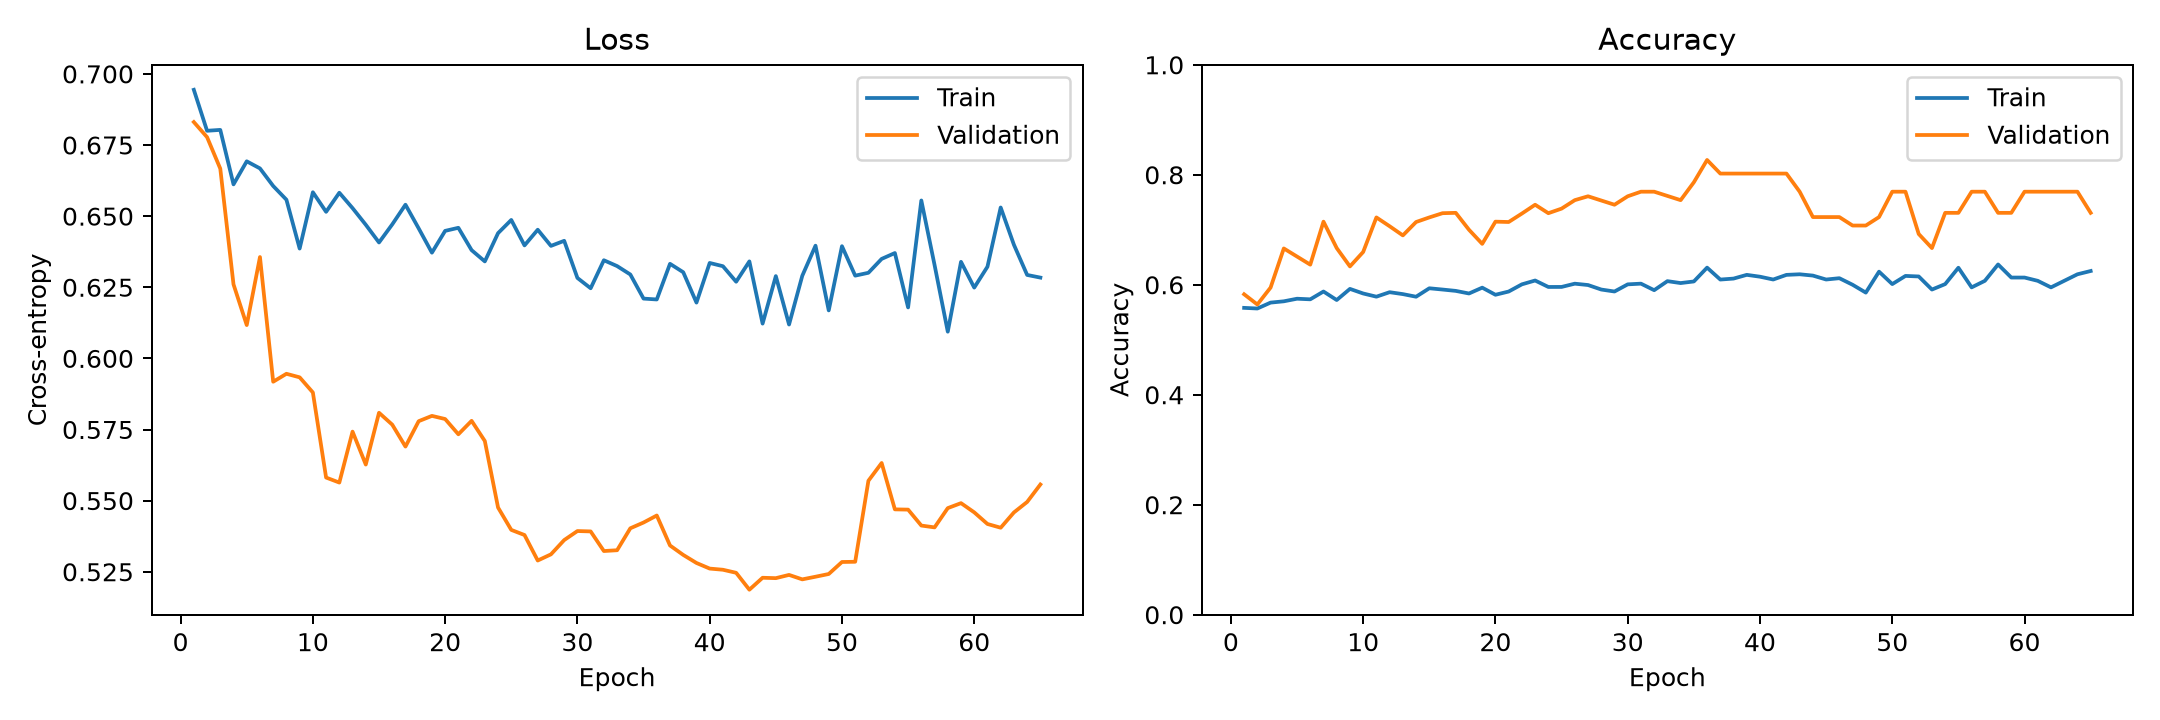

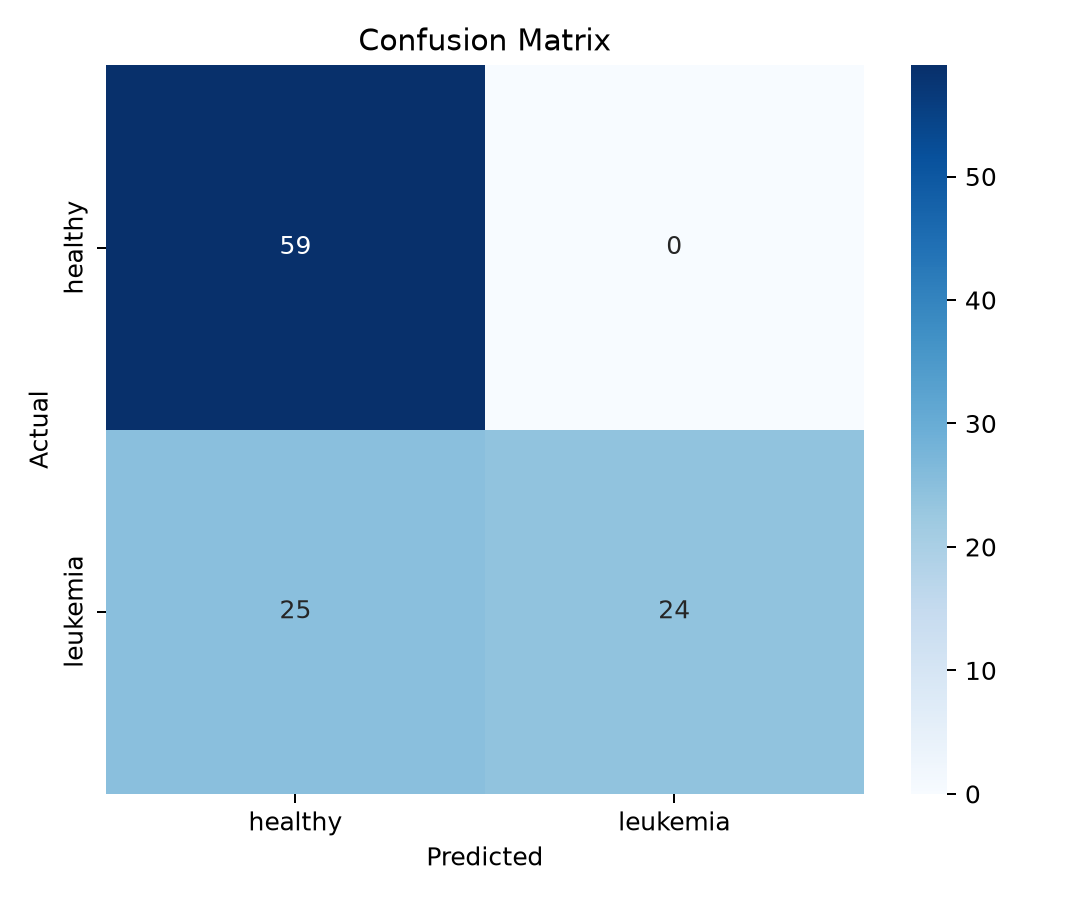

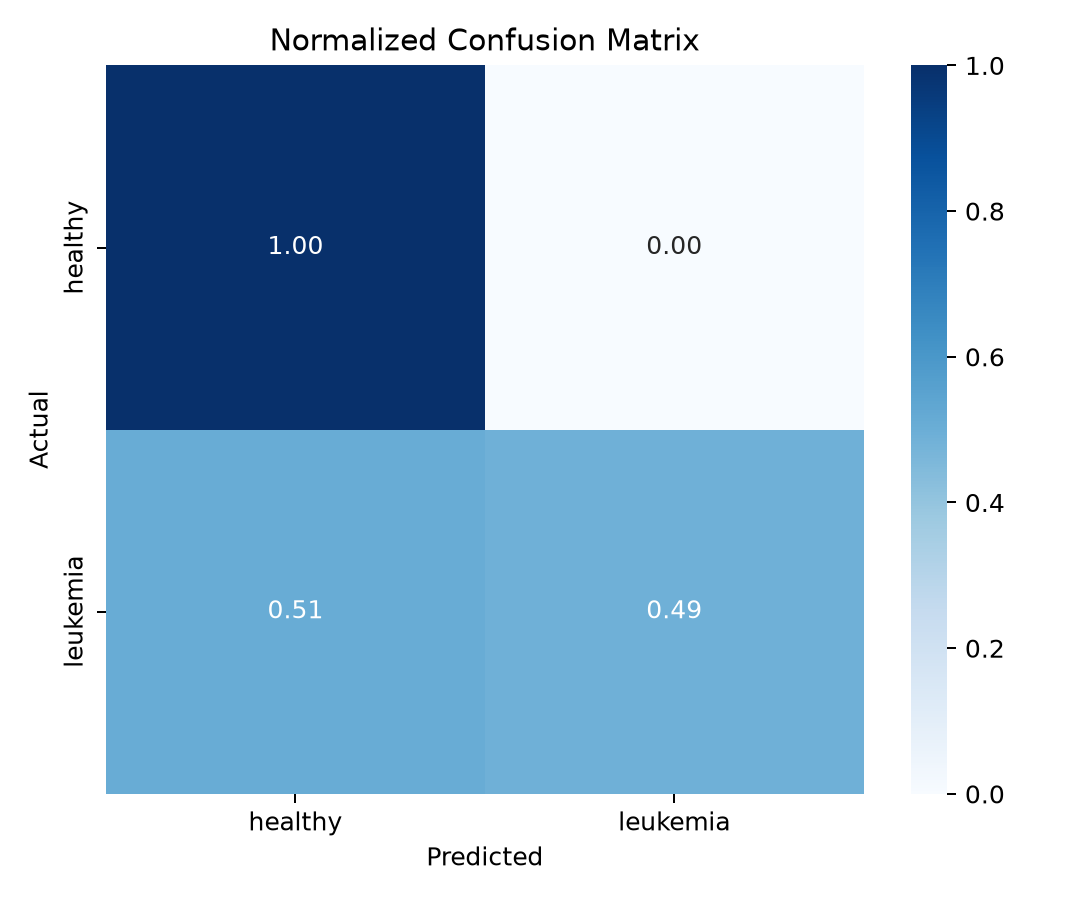

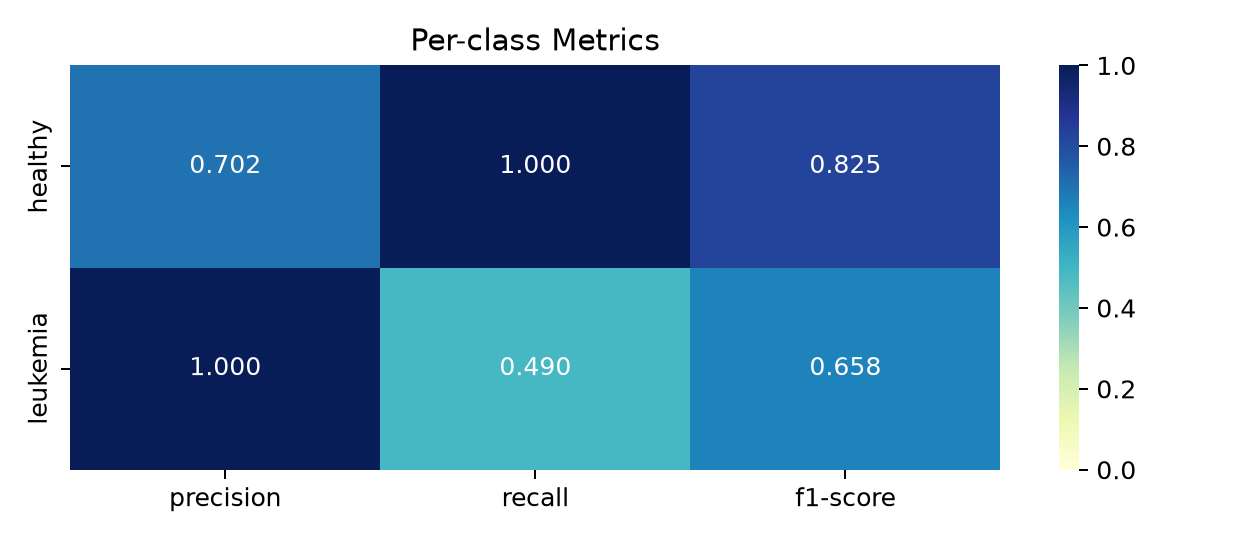

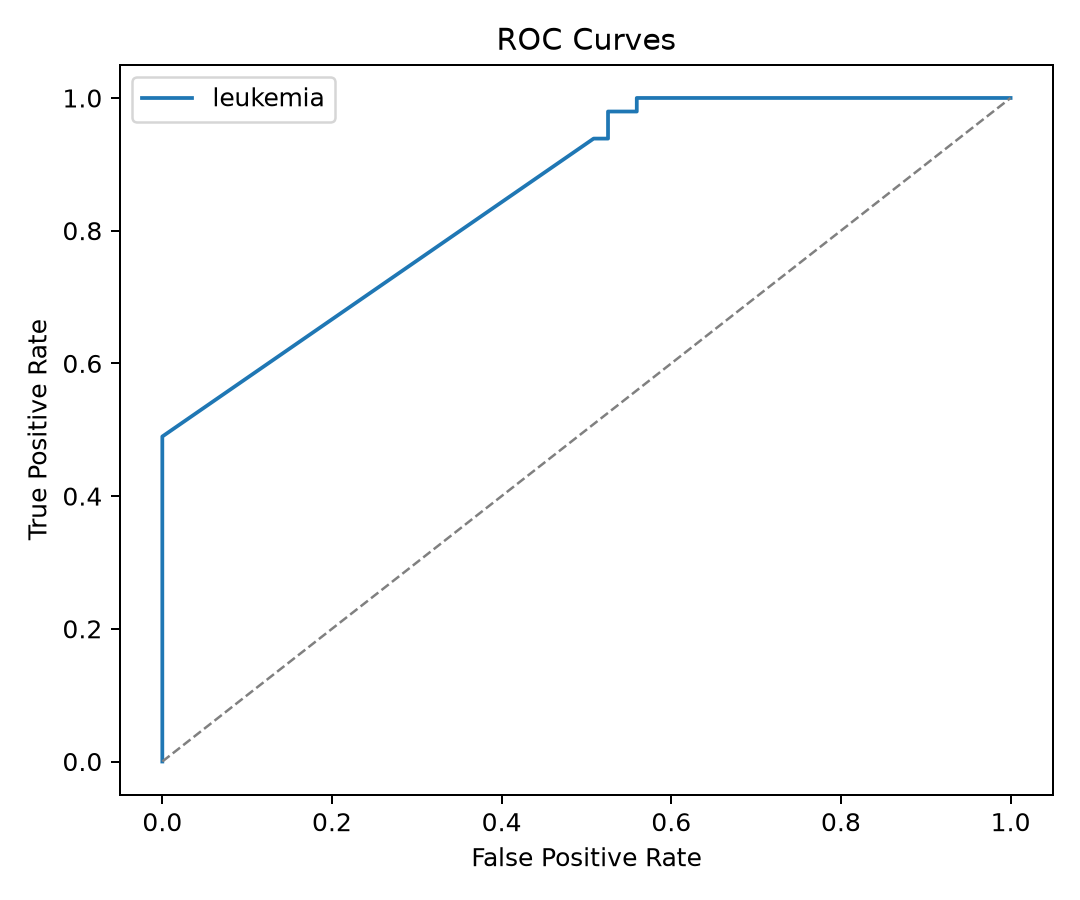

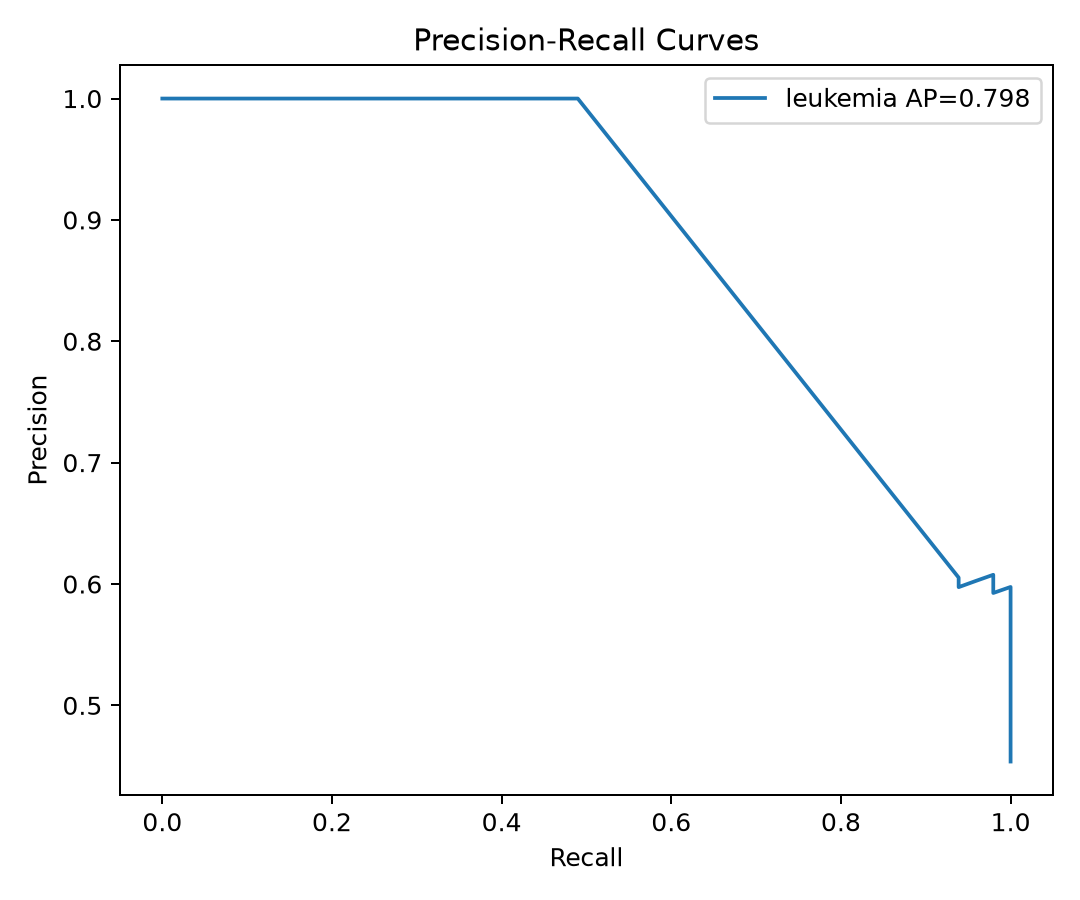

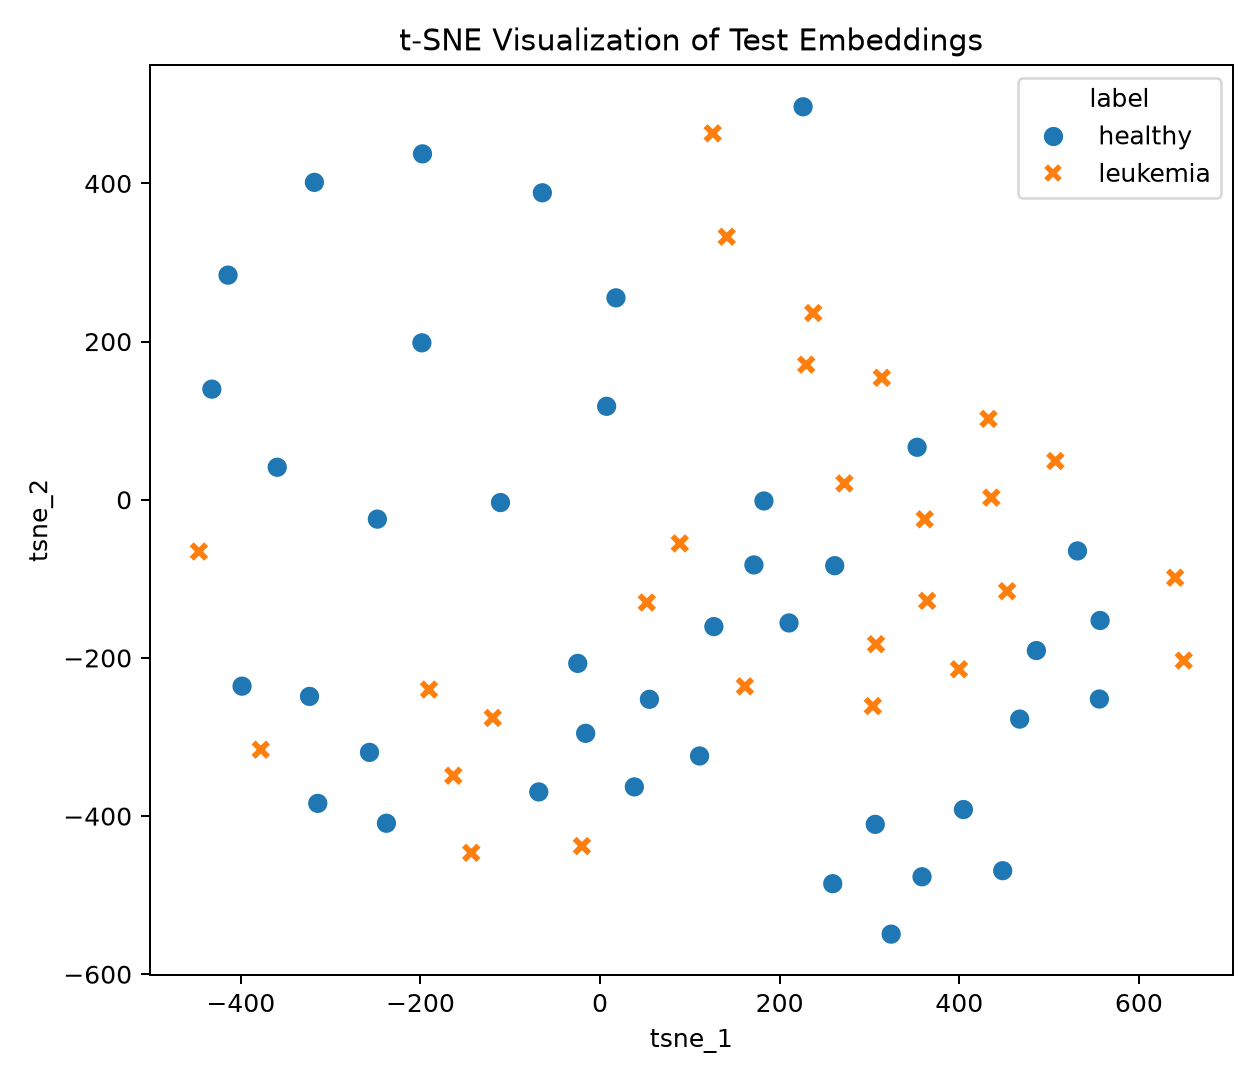

In [7]:
print("Saved result files:")
for result_path in sorted(RESULT_DIR.iterdir()):
    if result_path.is_file():
        print("-", result_path.name)

print("\nFinal metrics")
display(pd.read_csv(RESULT_DIR / "final_metrics.csv").T.rename(columns={0: "value"}))
print("\nPer-class classification metrics")
display(pd.read_csv(RESULT_DIR / "classification_metrics.csv", index_col=0))
print("\nPredictions")
display(pd.read_csv(RESULT_DIR / "predictions.csv"))

for plot_name in (
    "training_curves.png",
    "confusion_matrix_raw.png",
    "confusion_matrix_normalized.png",
    "classification_report.png",
    "roc_curves.png",
    "pr_curves.png",
    "tsne_visualization.png",
):
    plot_path = RESULT_DIR / plot_name
    if plot_path.is_file():
        display(Image(filename=str(plot_path)))

## Interpretation boundary

The architecture follows the paper diagram and literal diagonal OSL equation. The training
protocol cannot be an exact reproduction: the paper explicitly uses transfer learning and
does not report all hyperparameters, while this notebook forbids pretrained weights. Reported
numbers are measured from this run only and include duplicate-aware out-of-fold evaluation.